# TuneTale: KNN Testing & Evaluation

Loads the preprocessed training CSV from `eda.ipynb`, fits KNN, and evaluates recommendations using MeanDistance@K and Precision@K (genre match rate).

In [77]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

## 1. Load Preprocessed Data
Update `TRAIN_CSV`

In [99]:
TRAIN_CSV = "data/tracks_processed.csv"

df = pd.read_csv(TRAIN_CSV)

FEATURES = ["danceability", "energy", "loudness", "valence", "tempo",
            "acousticness", "speechiness", "instrumentalness", "liveness"]

print(f"Loaded {len(df):,} tracks")
df.head()

Loaded 81,343 tracks


,track_id,track_name,artists,album_name,track_genre,danceability,energy,loudness,valence,tempo,acousticness,speechiness,instrumentalness,liveness
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,0.686294,0.4610,0.791392,0.718593,0.361245,0.032329,0.148187,0.000001,0.3580
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,0.426396,0.1660,0.597377,0.268342,0.318397,0.927711,0.079067,0.000006,0.1010
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,0.444670,0.3590,0.736123,0.120603,0.313643,0.210843,0.057720,0.000000,0.1170
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,acoustic,0.270051,0.0596,0.573701,0.143719,0.746758,0.908635,0.037617,0.000071,0.1320
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,Hold On,acoustic,0.627411,0.4430,0.737103,0.167839,0.492863,0.470884,0.054508,0.000000,0.0829


## 2. Fit KNN on Audio Features

In [79]:
K = 10  # Returns the K nearest neighbors (excluding the track itself)

X = df[FEATURES].values

knn = NearestNeighbors(n_neighbors=K + 1, metric="euclidean", algorithm="ball_tree")
knn.fit(X)

print("KNN model fitted.")

KNN model fitted.


## 3. Recommendation Function

In [80]:
def recommend(song_name, artist_name=None, n=K, genre_filter=False):
    mask = df["track_name"].str.lower() == song_name.lower()
    if artist_name:
        mask &= df["artists"].str.lower().str.contains(artist_name.lower())

    matches = df[mask]
    if matches.empty:
        print(f"'{song_name}' not found in dataset.")
        return None

    idx = matches.index[0]
    query_genre = df.at[idx, "track_genre"]

    if genre_filter:
        # Fetch a large pool of neighbors to filter down to n same-genre results
        pool = min(len(df), n * 20)
        temp_knn = NearestNeighbors(n_neighbors=pool, metric="euclidean", algorithm="ball_tree")
        temp_knn.fit(X)
        distances, indices = temp_knn.kneighbors(X[idx].reshape(1, -1))
        candidates = [(i, d) for i, d in zip(indices[0][1:], distances[0][1:])
                      if df.at[i, "track_genre"] == query_genre][:n]
        if not candidates:
            print(f"No same-genre results found for genre '{query_genre}'.")
            return None
        neighbor_idx  = [c[0] for c in candidates]
        neighbor_dist = [c[1] for c in candidates]
    else:
        distances, indices = knn.kneighbors(X[idx].reshape(1, -1))
        neighbor_idx  = list(indices[0][1:n+1])
        neighbor_dist = list(distances[0][1:n+1])

    results = df.iloc[neighbor_idx][["track_name", "artists", "track_genre"]].copy()
    results["distance"] = [round(d, 4) for d in neighbor_dist]
    results = results.reset_index(drop=True)
    results.index += 1

    label = f"genre-filtered ({query_genre})" if genre_filter else "all genres"
    print(f"Query: '{df.at[idx, 'track_name']}' by {df.at[idx, 'artists']} [{query_genre}] — {label}\n")
    return results

## 4. Precision@K Evaluation

**Precision@K** = fraction of the K recommendations that share the same genre as the query song.

We sample `n_eval` songs from the dataset and average Precision@K across them.

In [91]:
def mean_distance_at_k(idx, k=K):
    distances, indices = knn.kneighbors(X[idx].reshape(1, -1))
    return distances[0][1:k+1].mean()


def evaluate(n_eval=70000, k=K, seed=42):
    rng = np.random.default_rng(seed)
    sample_idx = rng.choice(len(df), size=n_eval, replace=False)

    dist_scores  = [mean_distance_at_k(i, k) for i in sample_idx]
    genre_scores = []
    for i in sample_idx:
        query_genre = df.at[i, "track_genre"]
        _, indices = knn.kneighbors(X[i].reshape(1, -1))
        neighbor_genres = df.iloc[indices[0][1:k+1]]["track_genre"].values
        genre_scores.append(np.mean(neighbor_genres == query_genre))

    avg_dist  = np.mean(dist_scores)
    avg_genre = np.mean(genre_scores)

    print(f"Mean Distance@{k}  (n={n_eval}): {avg_dist:.4f}  (lower = more similar)")
    print(f"Precision@{k}      (n={n_eval}): {avg_genre:.4f}  ({avg_genre*100:.1f}% exact genre match)")
    print(f"Random baseline genre precision: {1/df['track_genre'].nunique():.4f}")
    return avg_dist, avg_genre, dist_scores, genre_scores


avg_dist, avg_genre, dist_scores, genre_scores = evaluate()

Mean Distance@10  (n=70000): 0.5641  (lower = more similar)
Precision@10      (n=70000): 0.0689  (6.9% exact genre match)
Random baseline genre precision: 0.0088


## 5. Score Distribution

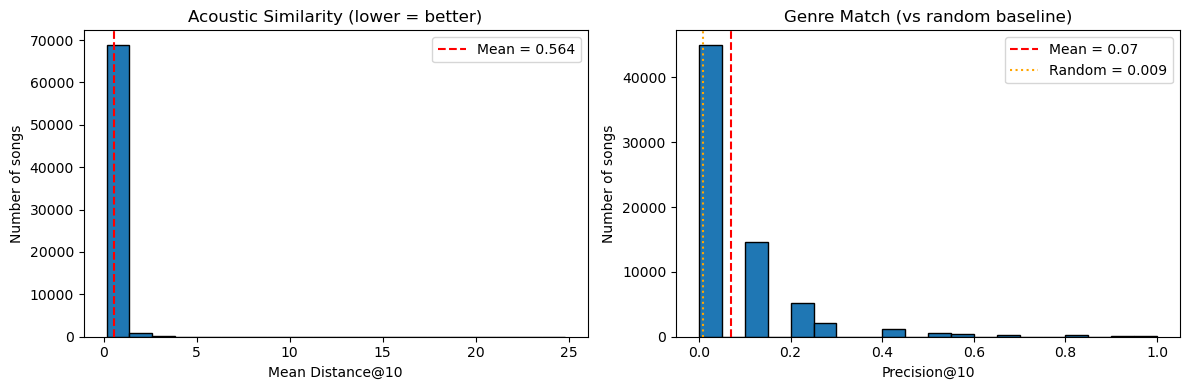

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dist_scores, bins=20, edgecolor="black")
axes[0].axvline(avg_dist, color="red", linestyle="--", label=f"Mean = {avg_dist:.3f}")
axes[0].set_xlabel(f"Mean Distance@{K}")
axes[0].set_ylabel("Number of songs")
axes[0].set_title(f"Acoustic Similarity (lower = better)")
axes[0].legend()

axes[1].hist(genre_scores, bins=20, edgecolor="black")
axes[1].axvline(avg_genre, color="red", linestyle="--", label=f"Mean = {avg_genre:.2f}")
axes[1].axvline(1/df["track_genre"].nunique(), color="orange", linestyle=":", label=f"Random = {1/df['track_genre'].nunique():.3f}")
axes[1].set_xlabel(f"Precision@{K}")
axes[1].set_ylabel("Number of songs")
axes[1].set_title(f"Genre Match (vs random baseline)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Trying a few Queries

In [95]:
# All genres (default)
recommend("Blinding Lights", artist_name="The Weeknd")

Query: 'Blinding Lights' by The Weeknd [pop] — all genres



,track_name,artists,track_genre,distance
1,Brave Shine,Aimer,anime,0.2942
2,Bitter Sweet Symphony,The Verve,alt-rock,0.4790
3,Bitter Sweet Symphony - Remastered 2016,The Verve,alt-rock,0.4794
4,La La La (Go Bromsten),Mwuana,dancehall,0.4825
5,Nascar,KillBunk,sad,0.5070
6,I Love It Loud,KISS,hard-rock,0.5232
7,МОЙ КАЛАШНИКОВ,FACE,emo,0.5354
8,Global - Edit,Korsakoff;Tha Watcher,happy,0.6007
9,Blinding Lights,Kidz Bop Kids,children,0.6060
10,Children Of The Night - Radio Edit,Nakatomi,happy,0.6123


In [96]:
# Same genre only
recommend("Blinding Lights", artist_name="The Weeknd", genre_filter=True)

No same-genre results found for genre 'pop'.


In [97]:
recommend("Sweater Weather", artist_name="The Neighbourhood", genre_filter=False)

Query: 'Sweater Weather' by The Neighbourhood [alt-rock] — all genres



,track_name,artists,track_genre,distance
1,Numb,Arc North;Aaron Richards;New Beat Order;Cour,edm,0.1990
2,Stay the Night,Sigala;Talia Mar,edm,0.2485
3,This Is What You Came For,Calvin Harris;Rihanna,dance,0.2508
4,Miracle,CHVRCHES,synth-pop,0.2851
5,Make Your Move,Anton Powers;Redondo,groove,0.2867
6,The Same Way,Don Diablo;KiFi,progressive-house,0.2926
7,W.D.Y.W.F.M?,The Neighbourhood,alt-rock,0.3124
8,Brass,Dirty Rush & Gregor Es,progressive-house,0.3164
9,Weisser Stern von Alcunar,NIC;Der Vollhorst,party,0.3375
10,Tão Iguais,Dead Fish,hard-rock,0.3667


In [98]:
recommend("Sweater Weather", artist_name="The Neighbourhood", genre_filter=True)

Query: 'Sweater Weather' by The Neighbourhood [alt-rock] — genre-filtered (alt-rock)



,track_name,artists,track_genre,distance
1,W.D.Y.W.F.M?,The Neighbourhood,alt-rock,0.3124
2,Broken,Seether;Amy Lee,alt-rock,0.4477
3,By the Way,Red Hot Chili Peppers,alt-rock,0.4887
4,Otherside,Red Hot Chili Peppers,alt-rock,0.9627
5,Pela Última Vez,NX Zero,alt-rock,0.9775


In [89]:
recommend("It will rain", artist_name="Bruno Mars")

Query: 'It Will Rain' by Bruno Mars [dance] — all genres



,track_name,artists,track_genre,distance
1,Gender,Jonathan Davis,industrial,0.2748
2,Stitches,Mini Pop Kids,kids,0.3028
3,Astronaut In The Ocean,Masked Wolf,hip-hop,0.3104
4,Ich liebe Dich - Aquagen Remix,Rick Arena;Deejay Biene;Aquagen;Moses C,disco,0.3372
5,When I Cry (feat. Ali Gatie),AYLIVA;Ali Gatie,german,0.3372
6,"Drop It Low, (Extended)",TNK;Jay Jones;Gundy;Wahu,turkish,0.3481
7,O Meri Jaan,Pritam;KK,indian,0.3482
8,Flores Secas,Skay Beilinson,metal,0.3553
9,Tu veneno,Calero LDN;BOXINBOX,spanish,0.3580
10,Crying For Love,Sonic Journey,dub,0.3825


In [90]:
recommend("It will rain", artist_name="Bruno Mars", genre_filter=True)

Query: 'It Will Rain' by Bruno Mars [dance] — genre-filtered (dance)



,track_name,artists,track_genre,distance
1,Stitches,Shawn Mendes,dance,0.5066
2,Baila Conmigo (with Rauw Alejandro),Selena Gomez;Rauw Alejandro,dance,0.6263
3,Baila Conmigo,Selena Gomez;Rauw Alejandro,dance,0.6281
